# Divers

In [1]:
# on fait une petite vérif...

from pathlib import Path        # pathlib est un module Python qui permet de manipuler les chemins de fichiers...

fichier = Path("/Users/sebastiensoncini/Documents/DataRockstars/foret.csv")     # le world-data-2023.csv a été renommé en foret.csv

print(fichier.exists())         # on demande si le fichier existe

True


In [2]:
import pandas as pd

# on lit le fichier csv qui a des lignes avec plein de virgule (avant qu'on l'ouvre avec excel)

df = pd.read_csv("/Users/sebastiensoncini/Documents/DataRockstars/foret.csv", sep=",")      # lit le contenu et fait un dataframe...

# sep="," pour dire que dans le fichier csv les colonnes sont séparés par des virgules

# on crée le fichier excel
df.to_excel("/Users/sebastiensoncini/Documents/DataRockstars/foret_colonnes_ok.xlsx", index = False)

# index = False ; on demande à VS code de ne pas exporter l'index dans excel

print("Conversion terminée.")

Conversion terminée.


# Nettoyage des données

### Observations

In [3]:
# on regarde le nb de colonnes etc... sur le fichier csv d'origine

import pandas as pd

df = pd.read_csv("/Users/sebastiensoncini/Documents/DataRockstars/foret.csv", sep=",")      # read_csv pour pour lire le fichier csv et le transformer en dataframe

print(df.head())                                                                            # head() pour afficher les premières lignes
print(df.info())                                                                            # info() donne le nb de lignes, de colonnes, de valeurs non-null, le type de donnée...
print(df.columns)                                                                           # columns pour voir les noms des colonnes

       Country Density\n(P/Km2) Abbreviation Agricultural Land( %)  \
0  Afghanistan               60           AF                58.10%   
1      Albania              105           AL                43.10%   
2      Algeria               18           DZ                17.40%   
3      Andorra              164           AD                40.00%   
4       Angola               26           AO                47.50%   

  Land Area(Km2) Armed Forces size  Birth Rate  Calling Code  \
0        652,230           323,000       32.49          93.0   
1         28,748             9,000       11.78         355.0   
2      2,381,741           317,000       24.28         213.0   
3            468               NaN        7.20         376.0   
4      1,246,700           117,000       40.73         244.0   

  Capital/Major City Co2-Emissions  ... Out of pocket health expenditure  \
0              Kabul         8,672  ...                           78.40%   
1             Tirana         4,536  ...   

In [4]:
# on regarde attentivement la colonne "Forested Area (%)"

# on regarde le nombre de valeurs manquantes

print(df["Forested Area (%)"].isna().sum())                     # isna() pour détecter les valeurs manquantes et sum() pour en faire le total ; isna() tout seul donnerait un True ou un False

# on regarde la proportion de valeurs manquantes

print(df["Forested Area (%)"].isna().mean() * 100)              # mean() pour calculer la moyenne

7
3.5897435897435894


In [5]:
# toujours la colonne des surfaces forestières

print(df["Forested Area (%)"].describe())                       # describe() fait un résumé statistique...

count        188
unique       161
top       43.10%
freq           3
Name: Forested Area (%), dtype: object


In [6]:
# les valeurs ne semblent pas être des nb pour vscode... regardons de plus près

print(df["Forested Area (%)"].head(20))                         # head(20) pour afficher les 20 premières lignes...

print(df["Forested Area (%)"].unique()[:20])                    # unique() pour donner les valeurs différentes de la colonne Forested Area... et [:20] pour donner les 20 premiers éléments du résultat

# remarquons que ici ça donne, presque, les mêmes résultats

0      2.10%
1     28.10%
2      0.80%
3     34.00%
4     46.30%
5     22.30%
6      9.80%
7     11.70%
8     16.30%
9     46.90%
10    14.10%
11    51.40%
12     0.80%
13    11.00%
14    14.70%
15    42.60%
16    22.60%
17    59.70%
18    37.80%
19    72.50%
Name: Forested Area (%), dtype: object
['2.10%' '28.10%' '0.80%' '34.00%' '46.30%' '22.30%' '9.80%' '11.70%'
 '16.30%' '46.90%' '14.10%' '51.40%' '11.00%' '14.70%' '42.60%' '22.60%'
 '59.70%' '37.80%' '72.50%' '50.30%']


### Premiers nettoyages - Suppression symbole inutile - Conversion vers valeur numérique

In [7]:
# les données sont de la forme "28.10%", il faut enlever le % puis les convertir en nombre

df["Forested Area (%)"] = df["Forested Area (%)"].str.replace("%", "")                      # str ; on indique à Pandas que l'on veut traiter les données comme du texte
df["Forested Area (%)"] = pd.to_numeric(df["Forested Area (%)"], errors="coerce")           # to_numeric() pour convertir en nombre

# "coerce" si une valeur ne peut pas être convertie, elle deviendra une NaN

In [8]:
# On vérifie le nouveau type des valeurs de la colonne de surface forestière

print(df["Forested Area (%)"].dtype)                                                        # dtype pour connaître le type de la donnée

# On vérifie qu'il y a le même nombre de valeurs manquantes qu'avant

print(df["Forested Area (%)"].isna().sum())

float64
7


### Détection des valeurs manquantes (1)

In [9]:
# on liste les colonnes qui ont des valauers manquantes, avec le nb de valeurs manquantes

import pandas as pd

df = pd.read_csv("foret.csv")

valeurs_manquantes = df.isna().sum()

print(valeurs_manquantes[valeurs_manquantes > 0])       # si une colonne n'a pas de valeur manquante, on ne l'affiche pas
                                                        # remarque : ici on a une espèce de condition dans le [], on demande à Pandas de sélectionner certaines valeurs du dataframe
                                                        # la petite différence avec un vrai if, c'est que l eif c'est pour tester une condition pour exécuter du code...

Abbreviation                                  7
Agricultural Land( %)                         7
Land Area(Km2)                                1
Armed Forces size                            24
Birth Rate                                    6
Calling Code                                  1
Capital/Major City                            3
Co2-Emissions                                 7
CPI                                          17
CPI Change (%)                               16
Currency-Code                                15
Fertility Rate                                7
Forested Area (%)                             7
Gasoline Price                               20
GDP                                           2
Gross primary education enrollment (%)        7
Gross tertiary education enrollment (%)      12
Infant mortality                              6
Largest city                                  6
Life expectancy                               8
Maternal mortality ratio                

In [10]:
# on vérifie qu'il n'y ait pas de pays en double

doublons = df.duplicated().sum()

print("Nombre de doublons :", doublons)

Nombre de doublons : 0


### Vérification des types de données

In [11]:
# on vérifie les types de données de chaque colonne

print(df.dtypes)

Country                                       object
Density\n(P/Km2)                              object
Abbreviation                                  object
Agricultural Land( %)                         object
Land Area(Km2)                                object
Armed Forces size                             object
Birth Rate                                   float64
Calling Code                                 float64
Capital/Major City                            object
Co2-Emissions                                 object
CPI                                           object
CPI Change (%)                                object
Currency-Code                                 object
Fertility Rate                               float64
Forested Area (%)                             object
Gasoline Price                                object
GDP                                           object
Gross primary education enrollment (%)        object
Gross tertiary education enrollment (%)       

In [12]:
# sauf que dans une colonne, il y a forcément toujours le même type ? Regardons plus précisément...

# regardons par exemple la colonne Land Area(Km2)

print(df["Land Area(Km2)"].apply(type).value_counts())              # apply(type) pour appliquer la fonction type() à caque valeur de la colonne Land Area ; fusionné avec un value_counts()

Land Area(Km2)
<class 'str'>      194
<class 'float'>      1
Name: count, dtype: int64


In [13]:
# c'est déjà pas seulement de "type object"... affichons les 1à premières valeurs

print(df["Land Area(Km2)"].head(10).tolist())                       # tolist() pour transformer du Pandas en une liste classique

['652,230', '28,748', '2,381,741', '468', '1,246,700', '443', '2,780,400', '29,743', '7,741,220', '83,871']


### Conversion vers des valeurs numériques

In [14]:
# toutes ces virgules, pandas ne voit pas cela comme des nombres...

# essayons de convertir une valeur...

valeur = "2,381,741"

valeur = valeur.replace(",", "")

print(valeur)

float(valeur)

print(valeur)

2381741
2381741


In [15]:
# on convertit toutes les valeurs de land area en nombre

df["Land Area(Km2)"] = (
    df["Land Area(Km2)"]
    .astype(str)                                                        # astype(str) pour convertir les valeurs en chaîne de caractères, donc en texte
    .str.replace(",", "", regex=False)                                  # regex=False pour dire que je ne veux pas utiliser les expressions régulières, je veux simplement remplacer ce caractère exact
)

df["Land Area(Km2)"] = pd.to_numeric(
    df["Land Area(Km2)"],
    errors="coerce"                                                     # errors="coerce" ; si il n'y a pas de valeur alors on met NaN
)

# on vérifie que ça a fonctionné

print(df["Land Area(Km2)"].dtype)
print(df["Land Area(Km2)"].apply(type).value_counts())

float64
Land Area(Km2)
<class 'float'>    195
Name: count, dtype: int64


### Détection de valeurs manquantes (2)

In [16]:
# ça a l'air d'avoir focntionné, on vérifie si y'a des valaurs manquantes

print(df["Land Area(Km2)"].isna().sum())

1


In [17]:
# il y a une valeur manquante, identifions la ligne concernée

print(df[df["Land Area(Km2)"].isna()])              # le df intérieur on sélectionne la colonne Land Area du df ; avec le isna() ça va donner une liste de True/False
                                                    # le df extérieur est une condition de filtrage ; on garde si isna() est vraie

                            Country Density\n(P/Km2) Abbreviation  \
133  Palestinian National Authority              847          NaN   

    Agricultural Land( %)  Land Area(Km2) Armed Forces size  Birth Rate  \
133                   NaN             NaN               NaN         NaN   

     Calling Code Capital/Major City Co2-Emissions  ...  \
133           NaN                NaN           NaN  ...   

    Out of pocket health expenditure Physicians per thousand Population  \
133                              NaN                     NaN        NaN   

     Population: Labor force participation (%) Tax revenue (%) Total tax rate  \
133                                        NaN             NaN            NaN   

    Unemployment rate Urban_population   Latitude  Longitude  
133               NaN              NaN  31.952162  35.233154  

[1 rows x 35 columns]


In [18]:
# réaffichons les noms des colonnes

print(df.columns.tolist())                  # tolist() pour transformer un objet Pandas en liste classique...

['Country', 'Density\n(P/Km2)', 'Abbreviation', 'Agricultural Land( %)', 'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code', 'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)', 'Currency-Code', 'Fertility Rate', 'Forested Area (%)', 'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)', 'Gross tertiary education enrollment (%)', 'Infant mortality', 'Largest city', 'Life expectancy', 'Maternal mortality ratio', 'Minimum wage', 'Official language', 'Out of pocket health expenditure', 'Physicians per thousand', 'Population', 'Population: Labor force participation (%)', 'Tax revenue (%)', 'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude']


### Colonnes inutiles

In [19]:
# liste des colonnes pas utile selon moi

colonnes_a_supprimer = [
    "Abbreviation",
    "Calling Code",
    "Capital/Major City",
    "Currency-Code",
    "Largest city",
    "Official language"
]

print(colonnes_a_supprimer)

['Abbreviation', 'Calling Code', 'Capital/Major City', 'Currency-Code', 'Largest city', 'Official language']


In [20]:
# on supprime les colonnes en question

df = df.drop(columns=colonnes_a_supprimer)                  # drop(columns) pour supprimer des colonnes, et il vaut mieux préciser quelles colonnes supprimer...

# on vérifie le résulat

print(df.columns.tolist())

# ainsi que le nb de colonnes

print("Nombre de colonnes :", len(df.columns))

['Country', 'Density\n(P/Km2)', 'Agricultural Land( %)', 'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Co2-Emissions', 'CPI', 'CPI Change (%)', 'Fertility Rate', 'Forested Area (%)', 'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)', 'Gross tertiary education enrollment (%)', 'Infant mortality', 'Life expectancy', 'Maternal mortality ratio', 'Minimum wage', 'Out of pocket health expenditure', 'Physicians per thousand', 'Population', 'Population: Labor force participation (%)', 'Tax revenue (%)', 'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude']
Nombre de colonnes : 29


### Détection de valeurs manquantes (3)

In [21]:
# on regarde de nouveau les valeurs manquantes

print(df.isna().sum())

Country                                       0
Density\n(P/Km2)                              0
Agricultural Land( %)                         7
Land Area(Km2)                                1
Armed Forces size                            24
Birth Rate                                    6
Co2-Emissions                                 7
CPI                                          17
CPI Change (%)                               16
Fertility Rate                                7
Forested Area (%)                             7
Gasoline Price                               20
GDP                                           2
Gross primary education enrollment (%)        7
Gross tertiary education enrollment (%)      12
Infant mortality                              6
Life expectancy                               8
Maternal mortality ratio                     14
Minimum wage                                 45
Out of pocket health expenditure              7
Physicians per thousand                 

In [22]:
# on indique la proportion de valeurs manquantes pour chaque colonne

manquantes = df.isna().sum()

pourcentage = (manquantes / len(df)) * 100

print(pd.DataFrame({                                            # DataFrame() pour créer un DataFrame ; à partir de données qu'on donne à Pandas
    "Valeurs manquantes": manquantes,
    "Pourcentage": pourcentage
}))

                                           Valeurs manquantes  Pourcentage
Country                                                     0     0.000000
Density\n(P/Km2)                                            0     0.000000
Agricultural Land( %)                                       7     3.589744
Land Area(Km2)                                              1     0.512821
Armed Forces size                                          24    12.307692
Birth Rate                                                  6     3.076923
Co2-Emissions                                               7     3.589744
CPI                                                        17     8.717949
CPI Change (%)                                             16     8.205128
Fertility Rate                                              7     3.589744
Forested Area (%)                                           7     3.589744
Gasoline Price                                             20    10.256410
GDP                      

### Détection des colonnes avec du format texte

In [23]:
# il y a encore beacoup de colonnes où pandas ne voit que du texte, vérifions de nouveau

colonnes_object = df.select_dtypes(include="object").columns                # select_dtypes() pour sélectionner selon le type de données

print(colonnes_object.tolist())

['Country', 'Density\n(P/Km2)', 'Agricultural Land( %)', 'Armed Forces size', 'Co2-Emissions', 'CPI', 'CPI Change (%)', 'Forested Area (%)', 'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)', 'Gross tertiary education enrollment (%)', 'Minimum wage', 'Out of pocket health expenditure', 'Population', 'Population: Labor force participation (%)', 'Tax revenue (%)', 'Total tax rate', 'Unemployment rate', 'Urban_population']


### Définition des colonnes numériques

In [24]:
# on définie les colonnes numériques

colonnes_numeriques = [
    "Density\n(P/Km2)",
    "Agricultural Land( %)",
    "Land Area(Km2)",
    "Armed Forces size",
    "Birth Rate",
    "Co2-Emissions",
    "CPI",
    "CPI Change (%)",
    "Fertility Rate",
    "Forested Area (%)",
    "Gasoline Price",
    "GDP",
    "Gross primary education enrollment (%)",
    "Gross tertiary education enrollment (%)",
    "Infant mortality",
    "Life expectancy",
    "Maternal mortality ratio",
    "Minimum wage",
    "Out of pocket health expenditure",
    "Physicians per thousand",
    "Population",
    "Population: Labor force participation (%)",
    "Tax revenue (%)",
    "Total tax rate",
    "Unemployment rate",
    "Urban_population",
    "Latitude",
    "Longitude"
]

In [25]:
# on vérifie que ces colonnes sont bien dans le csv

for colonne in colonnes_numeriques:
    if colonne in df.columns:
        print("OK :", colonne)
    else:
        print("ABSENTE :", colonne)

OK : Density
(P/Km2)
OK : Agricultural Land( %)
OK : Land Area(Km2)
OK : Armed Forces size
OK : Birth Rate
OK : Co2-Emissions
OK : CPI
OK : CPI Change (%)
OK : Fertility Rate
OK : Forested Area (%)
OK : Gasoline Price
OK : GDP
OK : Gross primary education enrollment (%)
OK : Gross tertiary education enrollment (%)
OK : Infant mortality
OK : Life expectancy
OK : Maternal mortality ratio
OK : Minimum wage
OK : Out of pocket health expenditure
OK : Physicians per thousand
OK : Population
OK : Population: Labor force participation (%)
OK : Tax revenue (%)
OK : Total tax rate
OK : Unemployment rate
OK : Urban_population
OK : Latitude
OK : Longitude


In [26]:
# on affiche les 5 premières valeurs de chaque colonne

for colonne in colonnes_numeriques:
    print("\n---", colonne, "---")
    print(df[colonne].dropna().head(5).tolist())                    # dropna() pour supprimer les lignes ou les colonnes qui contiennent des valeurs manquantes


--- Density
(P/Km2) ---
['60', '105', '18', '164', '26']

--- Agricultural Land( %) ---
['58.10%', '43.10%', '17.40%', '40.00%', '47.50%']

--- Land Area(Km2) ---
[652230.0, 28748.0, 2381741.0, 468.0, 1246700.0]

--- Armed Forces size ---
['323,000', '9,000', '317,000', '117,000', '0']

--- Birth Rate ---
[32.49, 11.78, 24.28, 7.2, 40.73]

--- Co2-Emissions ---
['8,672', '4,536', '150,006', '469', '34,693']

--- CPI ---
['149.9', '119.05', '151.36', '261.73', '113.81']

--- CPI Change (%) ---
['2.30%', '1.40%', '2.00%', '17.10%', '1.20%']

--- Fertility Rate ---
[4.47, 1.62, 3.02, 1.27, 5.52]

--- Forested Area (%) ---
['2.10%', '28.10%', '0.80%', '34.00%', '46.30%']

--- Gasoline Price ---
['$0.70 ', '$1.36 ', '$0.28 ', '$1.51 ', '$0.97 ']

--- GDP ---
['$19,101,353,833 ', '$15,278,077,447 ', '$169,988,236,398 ', '$3,154,057,987 ', '$94,635,415,870 ']

--- Gross primary education enrollment (%) ---
['104.00%', '107.00%', '109.90%', '106.40%', '113.50%']

--- Gross tertiary education 

### Définition des colonnes contenant des virgules - Suppression des virgules - Conversion vers des valeurs numériques

In [27]:
# il y a des colonnes où les valaurs ont plein de virgules... créons une catégorie pour ça

colonnes_virgules = [
    "Armed Forces size",
    "Co2-Emissions",
    "Population",
    "Urban_population"
]

# on applique alors le nettoyage, la conversion vers des nombres plus propre

for colonne in colonnes_virgules:
    df[colonne] = (
        df[colonne]
        .str.replace(",", "", regex=False)
        .astype(float)
    )

# on vérifie que ça s'est bien passé

print(df[colonnes_virgules].dtypes)
print(df[colonnes_virgules].head())


Armed Forces size    float64
Co2-Emissions        float64
Population           float64
Urban_population     float64
dtype: object
   Armed Forces size  Co2-Emissions  Population  Urban_population
0           323000.0         8672.0  38041754.0         9797273.0
1             9000.0         4536.0   2854191.0         1747593.0
2           317000.0       150006.0  43053054.0        31510100.0
3                NaN          469.0     77142.0           67873.0
4           117000.0        34693.0  31825295.0        21061025.0


### Définition des colonnes contenant des % - Suppression des % - Conversion vers des valeurs numériques

In [28]:
# maintenant on fait pareil avec les colonnes qui contiennent des %

colonnes_pourcentage = [
    "Agricultural Land( %)",
    "CPI Change (%)",
    "Forested Area (%)",
    "Gross primary education enrollment (%)",
    "Gross tertiary education enrollment (%)",
    "Out of pocket health expenditure",
    "Population: Labor force participation (%)",
    "Tax revenue (%)",
    "Total tax rate",
    "Unemployment rate"
]

for colonne in colonnes_pourcentage:
    df[colonne] = (
        df[colonne]
        .str.replace("%", "", regex=False)
        .astype(float)
    )

print(df[colonnes_pourcentage].dtypes)
print(df[colonnes_pourcentage].head())

Agricultural Land( %)                        float64
CPI Change (%)                               float64
Forested Area (%)                            float64
Gross primary education enrollment (%)       float64
Gross tertiary education enrollment (%)      float64
Out of pocket health expenditure             float64
Population: Labor force participation (%)    float64
Tax revenue (%)                              float64
Total tax rate                               float64
Unemployment rate                            float64
dtype: object
   Agricultural Land( %)  CPI Change (%)  Forested Area (%)  \
0                   58.1             2.3                2.1   
1                   43.1             1.4               28.1   
2                   17.4             2.0                0.8   
3                   40.0             NaN               34.0   
4                   47.5            17.1               46.3   

   Gross primary education enrollment (%)  \
0                               

### Définition des colonnes contenant des symboles dollard - Suppression des symboles - Conversion vers des valeurs numériques

In [29]:
# pareil avec les colonnes avec $

colonnes_dollars = [
    "Gasoline Price",
    "Minimum wage"
]

for colonne in colonnes_dollars:
    df[colonne] = (
        df[colonne]
        .str.replace("$", "", regex=False)
        .str.strip()
        .astype(float)
    )

print(df[colonnes_dollars].dtypes)
print(df[colonnes_dollars].head())

Gasoline Price    float64
Minimum wage      float64
dtype: object
   Gasoline Price  Minimum wage
0            0.70          0.43
1            1.36          1.12
2            0.28          0.95
3            1.51          6.63
4            0.97          0.71


### Définition des colonnes contenant des caractères dollard et virgules - Suppresion de ces caractères - Conversion vers des valeurs numériques

In [30]:
# maintenant les colonnes qui ont des virgules et des $

df["GDP"] = (
    df["GDP"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

print(df["GDP"].dtype)
print(df["GDP"].head())

float64
0    1.910135e+10
1    1.527808e+10
2    1.699882e+11
3    3.154058e+09
4    9.463542e+10
Name: GDP, dtype: float64


### Vérification des types de valeurs pour chaque colonne

In [31]:
# on refait un contrôle global

print(df.dtypes)

Country                                       object
Density\n(P/Km2)                              object
Agricultural Land( %)                        float64
Land Area(Km2)                               float64
Armed Forces size                            float64
Birth Rate                                   float64
Co2-Emissions                                float64
CPI                                           object
CPI Change (%)                               float64
Fertility Rate                               float64
Forested Area (%)                            float64
Gasoline Price                               float64
GDP                                          float64
Gross primary education enrollment (%)       float64
Gross tertiary education enrollment (%)      float64
Infant mortality                             float64
Life expectancy                              float64
Maternal mortality ratio                     float64
Minimum wage                                 f

### Conversion des colonnes Density et CPI vers des valeurs numériques

In [32]:
# on voit que les colonnes Density et CPI sont toujours des objets

# des nombres certes mais qui étient des textes pour le logiciel...

# vérifions de noiveaux ces colonnes

print(df["Density\n(P/Km2)"].head())
print(df["Density\n(P/Km2)"].apply(type).value_counts())                # apply(type) pour appliquer la focntion type() à chaque valeur de la colonne
                                                                        # type() pour connaître le type de valeur d'une variable
print(df["CPI"].head())
print(df["CPI"].apply(type).value_counts())

0     60
1    105
2     18
3    164
4     26
Name: Density\n(P/Km2), dtype: object
Density\n(P/Km2)
<class 'str'>    195
Name: count, dtype: int64
0     149.9
1    119.05
2    151.36
3       NaN
4    261.73
Name: CPI, dtype: object
CPI
<class 'str'>      178
<class 'float'>     17
Name: count, dtype: int64


In [33]:
# on corrige la colonnes Density...

df["Density\n(P/Km2)"] = pd.to_numeric(
    df["Density\n(P/Km2)"],
    errors="coerce"
)

print(df["Density\n(P/Km2)"].dtype)

float64


In [34]:
# et la colonne CPI...

df["CPI"] = pd.to_numeric(
    df["CPI"],
    errors="coerce"
)

print(df["CPI"].dtype)

float64


In [35]:
# on refait (encore) un contrôle global

print(df.dtypes)
print(df.select_dtypes(include="object").columns.tolist())      # cette ligne retourne uniquement les colonnes qui ont du texte réel

Country                                       object
Density\n(P/Km2)                             float64
Agricultural Land( %)                        float64
Land Area(Km2)                               float64
Armed Forces size                            float64
Birth Rate                                   float64
Co2-Emissions                                float64
CPI                                          float64
CPI Change (%)                               float64
Fertility Rate                               float64
Forested Area (%)                            float64
Gasoline Price                               float64
GDP                                          float64
Gross primary education enrollment (%)       float64
Gross tertiary education enrollment (%)      float64
Infant mortality                             float64
Life expectancy                              float64
Maternal mortality ratio                     float64
Minimum wage                                 f

### Détection des valeurs manquantes (4)

In [36]:
# tout est bien corrigé

# maintenant on fait un diagnostique avec une belle mise en forme

manquantes = df.isna().sum()
pourcentage = (manquantes / len(df)) * 100

diagnostic = pd.DataFrame({
    "Valeurs manquantes": manquantes,
    "Pourcentage": pourcentage
})

print(
    diagnostic[diagnostic["Valeurs manquantes"] > 0]
    .sort_values("Pourcentage", ascending=False)
)

                                           Valeurs manquantes  Pourcentage
Minimum wage                                               45    23.076923
Tax revenue (%)                                            26    13.333333
Armed Forces size                                          24    12.307692
Gasoline Price                                             20    10.256410
CPI                                                        20    10.256410
Unemployment rate                                          19     9.743590
Population: Labor force participation (%)                  19     9.743590
CPI Change (%)                                             16     8.205128
Maternal mortality ratio                                   14     7.179487
Total tax rate                                             12     6.153846
Gross tertiary education enrollment (%)                    12     6.153846
Life expectancy                                             8     4.102564
Agricultural Land( %)    

# Nettoyage effectué : génération de fichier excel et csv

### Générer du excel ou csv

In [37]:
# maintenant qu'on a tout bien nettoyé, on fait un fichier excel et un fichier csv avec tout ça

df.to_excel("foret_clean.xlsx", index=False)
df.to_csv("foret_clean.csv", index=False)
print("Fichiers excel et csv générés")

Fichiers excel et csv générés


### Vérification de la position dans l'ordinateur

In [38]:
# rien à voir... mais si on veut vérifier dans quel dossier on est actuellement sur l'oridinateur

import os

print(os.getcwd())

/Users/sebastiensoncini/Documents/DataRockstars


### Pays non identifié détecté - Recherche et correction

In [39]:
# on constate dans le fichier excel et le csv d'origine... qu'il y a une ligne "S???" au lieu que ce soit un pays

# alors dans csv c'est "S", dans le excel généré c'est S et plein de caractères bizarres

# affichons le contenu de cette ligne

print(df[df["Country"] == "S"])     # en fait ça va rien donné vu que c'est S???...

Empty DataFrame
Columns: [Country, Density
(P/Km2), Agricultural Land( %), Land Area(Km2), Armed Forces size, Birth Rate, Co2-Emissions, CPI, CPI Change (%), Fertility Rate, Forested Area (%), Gasoline Price, GDP, Gross primary education enrollment (%), Gross tertiary education enrollment (%), Infant mortality, Life expectancy, Maternal mortality ratio, Minimum wage, Out of pocket health expenditure, Physicians per thousand, Population, Population: Labor force participation (%), Tax revenue (%), Total tax rate, Unemployment rate, Urban_population, Latitude, Longitude]
Index: []

[0 rows x 29 columns]


In [40]:
# après recherche sur internet, le pays "S???" s'agit très probablement de Sao Tomé-et-Principe, une petite île près de l'Afrique centrale
# de plus la valeur dans "Land Area (km2) correspond bien"
# en Anglais, c'est São Tomé and Príncipe, nous allons le mettre dans le data, sans accent
# il s'agit de la ligne 152, mais numéro 150 pour pandas
# et oui, dans pandas on commence à partir de la ligne zéro (au lieu de 1 dans csv ou excel...)
# et la ligne d'en-tête n'est pas une donnée pour pandas

df.iloc[150, df.columns.get_loc("Country")] = "Sao Tome and Principe"               # iloc[] pour sélectionner lignes ou colonnes en utilisant leur position numérique
                                                                                    # get_loc() pour trouver la position d'un élément dans un index
# on vérifie que la correction s'est bien faite

print(df.iloc[149:152][["Country", "Density\n(P/Km2)"]])

                   Country  Density\n(P/Km2)
149             San Marino             566.0
150  Sao Tome and Principe             228.0
151           Saudi Arabia              16.0


In [41]:
# allez hop on refait les fichiers

df.to_excel("foret_clean.xlsx", index=False)
df.to_csv("foret_clean.csv", index=False)
print("Fichiers excel et csv générés")

Fichiers excel et csv générés


# Requête SQL

In [42]:
# on importe SQLite et on crée une base SQL qui servira pour la forêt...

import sqlite3

connexion = sqlite3.connect("foret.db")                 # connect() pour établir une connexion avec une base de données
                                                        # remarque : on peut créer la base de donnée directement dans la focntion connect()

In [43]:
# on envoie le DataFrame dans SQL

df.to_sql("forest", connexion, if_exists="replace", index=False)                # to_sql() pour envoyer un dataframe Pandas vers une table SQL

195

In [44]:
# on fait une 1ère requete SQL, on demande les pays avec la plus grande surface forestière
# les """...""" permettent de faire du texte à la ligne

requete = """
SELECT Country, "Forested Area (%)"
FROM forest
WHERE "Forested Area (%)" IS NOT NULL
ORDER BY "Forested Area (%)" DESC
LIMIT 10
"""

resultat = pd.read_sql_query(requete, connexion)                    # read_sql_query pour executer une requête SQL

print(resultat)

                          Country  Forested Area (%)
0                        Suriname               98.3
1  Federated States of Micronesia               91.9
2                           Gabon               90.0
3                      Seychelles               88.4
4                           Palau               87.6
5                          Guyana               83.9
6                            Laos               82.1
7                 Solomon Islands               77.9
8                Papua New Guinea               74.1
9                         Finland               73.1


# Analyse exploratoire

### Statistiques divers

In [64]:
# on regarde divers statistiques pour chaque colonne ; count = nb de valeurs non-manquantes ; std = écart-type

df.describe()

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Co2-Emissions,CPI,CPI Change (%),Fertility Rate,Forested Area (%),...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
count,188.000000,188.000000,1.940000e+02,1.710000e+02,189.000000,1.880000e+02,175.000000,179.000000,188.000000,188.000000,...,188.000000,188.000000,1.940000e+02,176.000000,169.000000,183.000000,176.000000,1.900000e+02,194.000000,194.000000
mean,139.281915,39.117553,6.896244e+05,1.592749e+05,20.214974,1.777992e+05,144.193600,6.722346,2.698138,32.015426,...,32.637234,1.839840,3.938116e+07,62.738068,16.573964,40.822404,6.886364,2.230454e+07,19.092351,20.232434
std,158.208082,21.783052,1.921609e+06,3.806288e+05,9.945774,8.387903e+05,54.783998,24.450414,1.282267,23.791331,...,19.172697,1.684261,1.450924e+08,10.502907,6.961632,20.557662,5.079216,7.543050e+07,23.961779,66.716110
min,2.000000,0.600000,0.000000e+00,0.000000e+00,5.900000,1.100000e+01,99.030000,-4.300000,0.980000,0.000000,...,0.200000,0.010000,8.360000e+02,38.000000,0.000000,8.000000,0.090000,5.464000e+03,-40.900557,-175.198242
25%,33.500000,21.700000,2.382825e+04,1.100000e+04,11.300000,2.304250e+03,113.670000,1.000000,1.705000,11.000000,...,17.450000,0.332500,1.962678e+06,56.150000,11.700000,30.600000,3.395000,1.152961e+06,4.544175,-7.941496
50%,83.000000,39.600000,1.195110e+05,3.100000e+04,17.950000,1.230300e+04,124.740000,2.300000,2.245000,32.000000,...,30.700000,1.460000,8.826588e+06,62.450000,16.300000,37.200000,5.360000,4.678104e+06,17.273849,20.972652
75%,203.000000,55.375000,5.242560e+05,1.420000e+05,28.750000,6.388425e+04,155.925000,4.250000,3.597500,48.175000,...,43.975000,2.935000,2.858549e+07,69.500000,21.100000,48.000000,9.490000,1.490324e+07,40.124603,48.281523
max,847.000000,82.600000,1.709824e+07,3.031000e+06,46.080000,9.893038e+06,550.930000,254.900000,6.910000,98.300000,...,81.600000,8.420000,1.397715e+09,86.800000,37.200000,219.600000,28.180000,8.429340e+08,64.963051,178.065032


In [65]:
# on se penche sur la colonne Forested Area (%)

df["Forested Area (%)"].describe()

count    188.000000
mean      32.015426
std       23.791331
min        0.000000
25%       11.000000
50%       32.000000
75%       48.175000
max       98.300000
Name: Forested Area (%), dtype: float64

In [66]:
# on regarde les 10 valeurs les plus élevés de surface forestière (%)

df["Forested Area (%)"].sort_values(ascending=False).head(10)

167    98.3
111    91.9
61     90.0
154    88.4
132    87.6
71     83.9
92     82.1
159    77.9
135    74.1
59     73.1
Name: Forested Area (%), dtype: float64

In [67]:
# on a eu les index des valeurs mais pas les pays concernés
# cette fois on veut les pays correspondant

df.loc[df["Forested Area (%)"].nlargest(10).index, ["Country", "Forested Area (%)"]]

,Country,Forested Area (%)
167,Suriname,98.3
111,Federated States of Micronesia,91.9
61,Gabon,90.0
154,Seychelles,88.4
132,Palau,87.6
71,Guyana,83.9
92,Laos,82.1
159,Solomon Islands,77.9
135,Papua New Guinea,74.1
59,Finland,73.1


On remarque que beaucoup de pays très forestiers sont des États tropicaux ou insulaires, avec quelques exceptions comme la Finlande.

In [68]:
# maintenant on regarde les pays avec le moins de forêt

df.loc[df["Forested Area (%)"].nsmallest(10).index, ["Country", "Forested Area (%)"]]

,Country,Forested Area (%)
130,Oman,0.0
141,Qatar,0.0
149,San Marino,0.0
51,Egypt,0.1
97,Libya,0.1
47,Djibouti,0.2
108,Mauritania,0.2
90,Kuwait,0.4
76,Iceland,0.5
151,Saudi Arabia,0.5


On retrouve beaucoup de pays arides ou désertiques, ce qui est assez logique.

### Corrélations en Forested Area (%) et les autres variables numériques

In [50]:
# on cherche les corrélations entre Forested Area (%) et les autres données

df.corr(numeric_only=True)["Forested Area (%)"].sort_values(ascending=False)

Forested Area (%)                            1.000000
Population: Labor force participation (%)    0.153807
Gasoline Price                               0.145923
Gross primary education enrollment (%)       0.144674
Tax revenue (%)                              0.122597
Longitude                                    0.033859
Total tax rate                               0.033275
CPI Change (%)                               0.015317
Life expectancy                              0.005900
GDP                                         -0.000565
Gross tertiary education enrollment (%)     -0.010183
Land Area(Km2)                              -0.014278
Armed Forces size                           -0.019928
Co2-Emissions                               -0.028803
Minimum wage                                -0.033010
Urban_population                            -0.034797
Population                                  -0.055625
Infant mortality                            -0.055932
Fertility Rate              

Forest Area (%) et Agricultural Land (%) ont une corrélation négative modérée. 

Autrement dit, dans ce jeu de données, les pays ayant une plus grande proportion de terres agricoles ont tendance à avoir une proportion de forêt plus faible.

C'est assez logique intuitivement : agriculture et forêt peuvent être en concurrence pour l'utilisation des terres.

### Corrélation entre Forested Area (%) et les terres agricoles (%)

<Axes: xlabel='Agricultural Land( %)', ylabel='Forested Area (%)'>

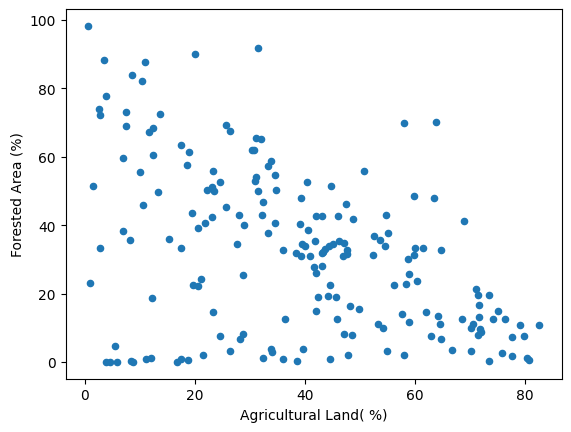

In [51]:
# on fait un nuage de points entre la forêt et les terres agricoles

df.plot.scatter(x="Agricultural Land( %)", y="Forested Area (%)")

In [60]:
# on crée une nouvelle colonne qui catégorise les terrains agricoles

df["Agriculture_categorie"] = pd.cut(
    df["Agricultural Land( %)"],
    bins=[0, 20, 40, 60, 80, float("inf")],
    labels=["0-20", "20-40", "40-60", "60-80", ">80"]
)

In [61]:
# on vérifie que ça a bien marché 

df[["Country", "Agricultural Land( %)", "Agriculture_categorie"]].head(10)

,Country,Agricultural Land( %),Agriculture_categorie
0,Afghanistan,58.1,40-60
1,Albania,43.1,40-60
2,Algeria,17.4,0-20
3,Andorra,40.0,20-40
4,Angola,47.5,40-60
5,Antigua and Barbuda,20.5,20-40
6,Argentina,54.3,40-60
7,Armenia,58.9,40-60
8,Australia,48.2,40-60
9,Austria,32.4,20-40


In [62]:
# nb de pays dans chaque catégorie

df["Agriculture_categorie"].value_counts().sort_index()

Agriculture_categorie
0-20     43
20-40    53
40-60    56
60-80    33
>80       3
Name: count, dtype: int64

Le dernier groupe est donc beaucoup trop petit pour en tirer une conclusion solide. Il est analysable, mais avec prudence.

In [63]:
# on calcule la médiane de Forested Area (%) pour chaque catégorie de terres agricoles

df.groupby("Agriculture_categorie", observed=True)["Forested Area (%)"].median()

Agriculture_categorie
0-20     49.80
20-40    40.60
40-60    31.25
60-80    12.60
>80       1.20
Name: Forested Area (%), dtype: float64

On observe une baisse très régulière :

49,8 → 40,6 → 31,25 → 12,6 → 1,2

Ici, le coefficient de corrélation de -0,435 prend sens : plus la proportion de terres agricoles est élevée, plus la médiane de couverture forestière tend à être faible.

Le groupe >80 % est à interpréter avec prudence puisqu'il ne contient que 3 pays, mais même sans lui, la tendance reste très nette.

### Corrélation entre Forested Area (%) et la densité de population (hab/km2)

In [52]:
# on regarde la corrélation entre Forest Area (%) et la densité de population (P/km2)

df["Density\n(P/Km2)"].corr(df["Forested Area (%)"])

np.float64(-0.06913745325370868)

La densité de population ne semble pas, à elle seule, expliquer beaucoup les différences de couverture forestière entre les pays.

Mais il y a une subtilité : la densité peut être très élevée dans de petits pays et très faible dans de grands pays, et notre graphique pourrait nous montrer une structure que le simple coefficient ne révèle pas très bien.

<Axes: xlabel='Density\n(P/Km2)', ylabel='Forested Area (%)'>

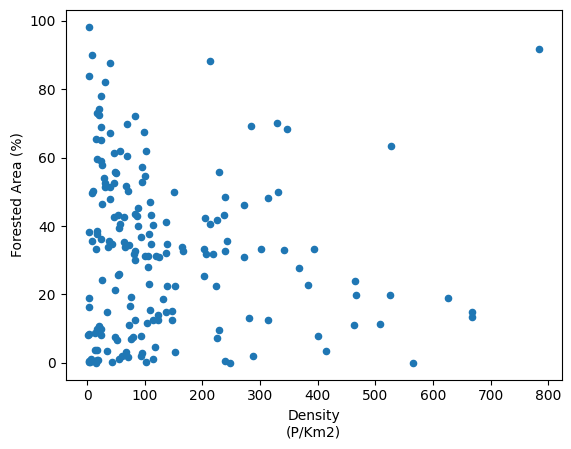

In [53]:
# nuage de point

df.plot.scatter(
    x="Density\n(P/Km2)",
    y="Forested Area (%)"
)

Le coefficient -0,069 nous dit seulement qu'il n'y a pratiquement pas de relation linéaire. Il ne dit pas qu'il n'y a aucune structure dans le nuage.

Or sur le graphique, il se dessine une sorte de triangle :
- énormément de pays sont concentrés dans les faibles densités ;
- quand la densité augmente, les valeurs de forêt semblent davantage se concentrer vers le bas ;
- mais il y a aussi quelques pays très denses qui étirent énormément l'axe horizontal.

Donc la densité ne présente pas une corrélation linéaire forte avec la forêt, pour autant le graphique mérite d'être étudié davantage.

Idée : zoomer sur les pays dont la densité est inférieure ou égale à 200 habitants/km².

<Axes: xlabel='Density\n(P/Km2)', ylabel='Forested Area (%)'>

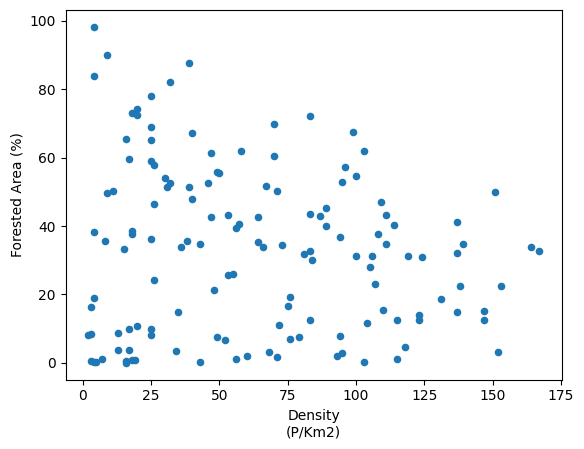

In [54]:
# on enlève les pays extrêmement denses ; pays avec densité inférieur à 200 hab/km2

df[df["Density\n(P/Km2)"] <= 200].plot.scatter(
    x="Density\n(P/Km2)",
    y="Forested Area (%)"
)

En retirant les quelques pays avec une densité supérieure à 200, on remarque que :
- à faible densité, la forêt peut être presque n'importe où entre 0 et 100 % ;
- quand la densité augmente, on voit de moins en moins de pays avec une très forte couverture forestière ;
- mais la dispersion reste importante : une densité de 100–150 habitants/km² peut encore correspondre à 5 %, 30 % ou 60 % de forêt.

In [55]:
# corrélation pour les pays avec densité inférieur à 200 hab/km2

df[df["Density\n(P/Km2)"] <= 200]["Density\n(P/Km2)"].corr(
    df[df["Density\n(P/Km2)"] <= 200]["Forested Area (%)"]
)

np.float64(-0.1403051502776498)

La relation négative devient un peu plus visible pour les pays avec une densité inférieur à 200 hab/km2, mais elle reste faible.

Regardons la médiane de forêt selon les tranches de densité.

In [56]:
# on crée les catégories

df["Densite_categorie"] = pd.cut(
    df["Density\n(P/Km2)"],
    bins=[0, 20, 50, 100, 200, float("inf")],
    labels=["0-20", "20-50", "50-100", "100-200", ">200"]
)

In [57]:
# on vérifie que la colonne Densité_Catégorie a bien été créee

df[["Country", "Density\n(P/Km2)", "Densite_categorie"]].head(10)

,Country,Density\n(P/Km2),Densite_categorie
0,Afghanistan,60.0,50-100
1,Albania,105.0,100-200
2,Algeria,18.0,0-20
3,Andorra,164.0,100-200
4,Angola,26.0,20-50
5,Antigua and Barbuda,223.0,>200
6,Argentina,17.0,0-20
7,Armenia,104.0,100-200
8,Australia,3.0,0-20
9,Austria,109.0,100-200


In [58]:
# on calcule la médiane de Forested Area (%) pour chaque catégorie

df.groupby("Densite_categorie", observed=True)["Forested Area (%)"].median()

Densite_categorie
0-20       17.60
20-50      51.30
50-100     34.15
100-200    25.50
>200       31.35
Name: Forested Area (%), dtype: float64

Il y a bien une baisse globale de la médiane quand on passe des densités intermédiaires vers les densités élevées :

51,3 % → 34,15 % → 25,5 %

Mais il y a une grosse particularité : la catégorie 0–20 n'a qu'une médiane de 17,6 %, alors que la catégorie 20–50 monte à 51,3 %.

Donc ce n'est clairement pas une relation simplement "plus la densité augmente, moins il y a de forêt".

Il y a probablement plusieurs phénomènes mélangés : les pays très peu denses comprennent notamment des pays désertiques, tandis que certains pays peu ou moyennement denses sont extrêmement forestiers.

Regardons combien de pays se trouvent dans chaque catégorie, parce qu'une médiane de 20-50 n'a pas la même valeur analytique si elle repose sur 5 pays ou sur 50.

In [59]:
df["Densite_categorie"].value_counts().sort_index()

Densite_categorie
0-20       33
20-50      31
50-100     44
100-200    32
>200       48
Name: count, dtype: int64

Les catégories sont assez bien représentées :
- 0–20 : 33 pays
- 20–50 : 31 pays
- 50–100 : 44 pays
- 100–200 : 32 pays
- plus de 200 : 48 pays

Donc aucune des médianes ne repose sur un tout petit échantillon. Elles sont donc toutes représentatives.

Remarque assez intéressante : la catégorie >200 contient même 48 pays, mais sa médiane de forêt remonte à 31,35 %. Ça confirme encore une fois que la relation avec la densité n'est pas monotone.